2026-02-05 07:10:38.451487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770275438.644350     213 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770275438.695961     213 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770275439.127795     213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770275439.127858     213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770275439.127861     213 computation_placer.cc:177] computation placer alr

Device: cuda
Loading SDXL...


Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionXLImg2ImgPipeline and will be ignored.


...


--- Share Configuration ---


Total Shares (N) [Default 5]:  8
Required Shares (K) [Default 3]:  5


Using Configuration: N=8, K=5



Password:  ········


Encrypting...
Embedding (Header + Data)...
Payload: 90487 bytes
Split Config: K=5, N=8
Share 1/8 (144816 bits)...
  Try 1: Gen... OK.
Share 2/8 (144816 bits)...
  Try 1: Gen... OK.
Share 3/8 (144816 bits)...
  Try 1: Gen... OK.
Share 4/8 (144816 bits)...
  Try 1: Gen... OK.
Share 5/8 (144816 bits)...
  Try 1: Gen... OK.
Share 6/8 (144816 bits)...
  Try 1: Gen... OK.
Share 7/8 (144816 bits)...
  Try 1: Gen... OK.
Share 8/8 (144816 bits)...
  Try 1: Gen... OK.


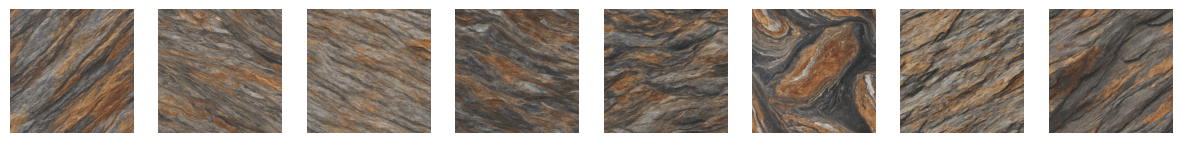

Recovering (Blind extraction)...
  Found Share ID: 5 | Len: 18098
  Found Share ID: 0 | Len: 18098
  Found Share ID: 6 | Len: 18098
  Found Share ID: 1 | Len: 18098
  Found Share ID: 2 | Len: 18098
Integrity Check: PASSED (Match)
Saved: /kaggle/working/Recovered.tiff
MSE: 0.0000


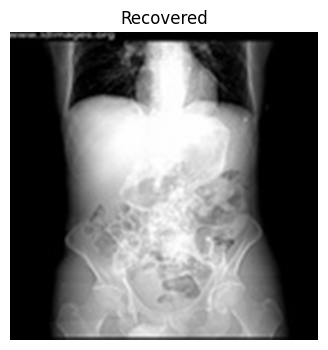

In [1]:
import os
import math
import random
import io
import getpass
import warnings
import struct
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")

WORK_DIR = os.environ.get('KAGGLE_WORKDIR', '/kaggle/working')
os.makedirs(WORK_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

COVER_RES = 1024
SEED_KEY = 42

OPTIM_STEPS = 100
LEARNING_RATE = 0.05     
SAFETY_MARGIN = 12       
MAX_RETRIES = 5
INFERENCE_STEPS = 40

NEGATIVE_PROMPT = "extra heads, two heads, mutated hands, poorly drawn hands, extra limbs, missing limbs, floating limbs, disconnected limbs, blurry, low quality, watermarks, text, duplication, deformed, ugly, bad anatomy"

try:
    import zfec
    import lzma
    from Crypto.Cipher import ChaCha20_Poly1305
    from Crypto.Random import get_random_bytes
    from Crypto.Protocol.KDF import scrypt
    from diffusers import StableDiffusionXLPipeline, StableDiffusionXLImg2ImgPipeline, DPMSolverMultistepScheduler
except ImportError:
    import subprocess
    print("Installing dependencies...")
    subprocess.run(["pip", "install", "zfec", "pycryptodome", "diffusers", "transformers", "accelerate"], check=False)
    import zfec
    import lzma
    from Crypto.Cipher import ChaCha20_Poly1305
    from Crypto.Random import get_random_bytes
    from Crypto.Protocol.KDF import scrypt
    from diffusers import StableDiffusionXLPipeline, StableDiffusionXLImg2ImgPipeline, DPMSolverMultistepScheduler

print(f"Device: {DEVICE}")

base_pipe = None
refiner_pipe = None

try:
    print("Loading SDXL...")
    base_pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        dtype=torch.float16,
        variant="fp16",
        use_safetensors=True
    )
    base_pipe.scheduler = DPMSolverMultistepScheduler.from_config(base_pipe.scheduler.config, use_karras_sigmas=True)
    base_pipe.set_progress_bar_config(disable=True)

    refiner_pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-refiner-1.0",
        text_encoder_2=base_pipe.text_encoder_2,
        vae=base_pipe.vae,
        dtype=torch.float16,
        use_safetensors=True,
        variant="fp16"
    )
    refiner_pipe.scheduler = DPMSolverMultistepScheduler.from_config(refiner_pipe.scheduler.config, use_karras_sigmas=True)
    refiner_pipe.set_progress_bar_config(disable=True)

    if DEVICE == "cuda":
        base_pipe.enable_model_cpu_offload()
        refiner_pipe.enable_model_cpu_offload()
        base_pipe.enable_vae_slicing()
        refiner_pipe.enable_vae_slicing()

except Exception as e:
    print(f"Model load error: {e}")

class IntegerHaarTransform:
    def forward(self, data_bytes):
        arr = np.frombuffer(data_bytes, dtype=np.uint8).astype(np.int16)
        if len(arr) % 2 != 0: arr = np.append(arr, 0)
        even = arr[0::2]
        odd = arr[1::2]
        detail = odd - even
        average = even + np.floor_divide(detail, 2)
        return np.concatenate((average, detail)).astype(np.int16).tobytes()

    def inverse(self, data_bytes):
        arr = np.frombuffer(data_bytes, dtype=np.int16)
        half = len(arr) // 2
        average = arr[:half]
        detail = arr[half:]
        even = average - np.floor_divide(detail, 2)
        odd = detail + even
        reconstructed = np.zeros(len(even) + len(odd), dtype=np.int16)
        reconstructed[0::2] = even
        reconstructed[1::2] = odd
        return reconstructed.astype(np.uint8).tobytes()

class SecureProcessor:
    def __init__(self, password):
        self.iwt = IntegerHaarTransform()
        self.password = password.encode('utf-8')
        self.lzma_filters = [{"id": lzma.FILTER_LZMA2, "preset": 9}]

    def _derive_key(self, salt):
        return scrypt(self.password, salt, 32, N=2**14, r=8, p=1)

    def pack(self, image_path):
        img = Image.open(image_path).convert('L')
        raw_bytes = img.tobytes()
        size = img.size
        
        iwt_data = self.iwt.forward(raw_bytes)
        comp_data = lzma.compress(iwt_data, format=lzma.FORMAT_RAW, filters=self.lzma_filters)
        
        salt = get_random_bytes(16)
        key = self._derive_key(salt)
        cipher = ChaCha20_Poly1305.new(key=key)
        ciphertext, tag = cipher.encrypt_and_digest(comp_data)
        
        return salt + cipher.nonce + tag + ciphertext, size

    def unpack(self, encrypted_payload, size):
        try:
            salt = encrypted_payload[:16]
            nonce = encrypted_payload[16:28]
            tag = encrypted_payload[28:44]
            ciphertext = encrypted_payload[44:]
            
            key = self._derive_key(salt)
            cipher = ChaCha20_Poly1305.new(key=key, nonce=nonce)
            comp_data = cipher.decrypt_and_verify(ciphertext, tag)
            
            decompressor = lzma.LZMADecompressor(format=lzma.FORMAT_RAW, filters=self.lzma_filters)
            iwt_data = decompressor.decompress(comp_data)
            raw_bytes = self.iwt.inverse(iwt_data)
            
            expected_len = size[0] * size[1]
            return Image.frombytes('L', size, raw_bytes[:expected_len])
        except Exception:
            return None

class KeylessStegoEngine:
    HEADER_BITS = 32

    def get_pixel_indices(self, total_pixels, num_bits):
        np.random.seed(SEED_KEY)
        W = COVER_RES
        indices = np.random.permutation(total_pixels - W - 2)
        
        total_needed = num_bits * 2
        if len(indices) < total_needed:
            raise ValueError("Payload too large.")
            
        idx_a = indices[0 : total_needed : 2]
        idx_b = indices[1 : total_needed : 2]
        return idx_a, idx_b

    def get_texture_energy(self, arr_rgb, indices, W):
        intensity = np.sum(arr_rgb, axis=1).astype(np.int32) 
        p0 = intensity[indices]
        p1 = intensity[indices + 1]
        p2 = intensity[indices + W]
        p3 = intensity[indices + W + 1]
        return p0 - p1 - p2 + p3

    def extract_bits(self, img_arr, num_bits):
        H, W, C = img_arr.shape
        flat_rgb = img_arr.reshape(-1, 3)
        idx_a, idx_b = self.get_pixel_indices(len(flat_rgb), num_bits)
        en_a = self.get_texture_energy(flat_rgb, idx_a, W)
        en_b = self.get_texture_energy(flat_rgb, idx_b, W)
        return (en_a > en_b).astype(np.uint8)

    def optimize_candidate(self, init_image, target_bits, num_steps=OPTIM_STEPS):
        img_arr_init = np.array(init_image.convert('RGB')) / 255.0
        img_tensor = torch.tensor(img_arr_init, dtype=torch.float32, device=DEVICE)
        img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0) 
        img_tensor.requires_grad = True
        
        original_tensor = img_tensor.clone().detach()
        optimizer = optim.Adam([img_tensor], lr=LEARNING_RATE)
        target_tensor = torch.tensor(target_bits, dtype=torch.float32, device=DEVICE)
        
        H, W = init_image.height, init_image.width
        idx_a, idx_b = self.get_pixel_indices(H * W, len(target_bits))
        
        t_idx_a = torch.tensor(idx_a, device=DEVICE)
        t_idx_b = torch.tensor(idx_b, device=DEVICE)
        
        off0, off1, off2, off3 = 0, 1, W, W + 1

        for _ in range(num_steps):
            optimizer.zero_grad()
            flat_pixels = img_tensor.squeeze(0).permute(1, 2, 0).reshape(-1, 3)
            intensity = torch.sum(flat_pixels, dim=1)
            
            def get_tensor_energy(indices):
                p0 = intensity[indices + off0]
                p1 = intensity[indices + off1]
                p2 = intensity[indices + off2]
                p3 = intensity[indices + off3]
                return p0 - p1 - p2 + p3

            en_a = get_tensor_energy(t_idx_a)
            en_b = get_tensor_energy(t_idx_b)
            
            pred_bits = torch.sigmoid((en_a - en_b) * 10) 
            
            stego_loss = nn.BCELoss()(pred_bits, target_tensor)
            visual_loss = nn.MSELoss()(img_tensor, original_tensor)
            total_loss = stego_loss + (0.01 * visual_loss)
            
            total_loss.backward()
            optimizer.step()
            with torch.no_grad(): img_tensor.data.clamp_(0, 1)
        
        res = img_tensor.squeeze().permute(1, 2, 0).detach().cpu().numpy()
        return (res * 255).astype(np.uint8)

    def force_fix(self, img_arr, target_bits):
        H, W, C = img_arr.shape
        flat_rgb = img_arr.reshape(-1, 3).astype(np.int32)
        idx_a, idx_b = self.get_pixel_indices(len(flat_rgb), len(target_bits))
        
        for _ in range(3):
            intensity = np.sum(flat_rgb, axis=1)
            p0 = intensity[idx_a]; p1 = intensity[idx_a + 1]; p2 = intensity[idx_a + W]; p3 = intensity[idx_a + W + 1]
            energy_a = p0 - p1 - p2 + p3
            
            p0b = intensity[idx_b]; p1b = intensity[idx_b + 1]; p2b = intensity[idx_b + W]; p3b = intensity[idx_b + W + 1]
            energy_b = p0b - p1b - p2b + p3b
            
            current_bits = (energy_a > energy_b).astype(np.uint8)
            errors = (current_bits != target_bits)
            if np.sum(errors) == 0: break

            error_indices = np.where(errors)[0]
            for i in error_indices:
                pA, pB = idx_a[i], idx_b[i]
                target = target_bits[i]
                margin = SAFETY_MARGIN
                
                val_ea = energy_a[i]
                val_eb = energy_b[i]
                
                if target == 1: 
                    gap = val_ea - val_eb
                    needed = margin - gap
                    if needed > 0:
                        chan_delta = int(math.ceil(needed / 6.0)) + 1 
                        flat_rgb[pA] += chan_delta; flat_rgb[pA+1] -= chan_delta; flat_rgb[pA+W] -= chan_delta; flat_rgb[pA+W+1] += chan_delta
                        flat_rgb[pB] -= chan_delta; flat_rgb[pB+1] += chan_delta; flat_rgb[pB+W] += chan_delta; flat_rgb[pB+W+1] -= chan_delta
                else: 
                    gap = val_eb - val_ea
                    needed = margin - gap
                    if needed > 0:
                        chan_delta = int(math.ceil(needed / 6.0)) + 1
                        flat_rgb[pA] -= chan_delta; flat_rgb[pA+1] += chan_delta; flat_rgb[pA+W] += chan_delta; flat_rgb[pA+W+1] -= chan_delta
                        flat_rgb[pB] += chan_delta; flat_rgb[pB+1] -= chan_delta; flat_rgb[pB+W] -= chan_delta; flat_rgb[pB+W+1] += chan_delta
        
        np.clip(flat_rgb, 0, 255, out=flat_rgb)
        return Image.fromarray(flat_rgb.astype(np.uint8).reshape(H, W, 3))

    def generate_cover(self, prompt, seed):
        if base_pipe is None: 
            return Image.fromarray(np.random.randint(0,255,(COVER_RES,COVER_RES,3),dtype=np.uint8))
        
        gen = torch.Generator(device=DEVICE).manual_seed(seed)
        latents = base_pipe(
            prompt=prompt + ", masterpiece, 8k, highly detailed, texture",
            negative_prompt=NEGATIVE_PROMPT,
            num_inference_steps=INFERENCE_STEPS,
            denoising_end=0.8,
            height=COVER_RES, width=COVER_RES,
            output_type="latent",
            generator=gen
        ).images
        
        image = refiner_pipe(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            num_inference_steps=INFERENCE_STEPS,
            denoising_start=0.8,
            image=latents,
            generator=gen
        ).images[0]
        return image

    def create_bitstream(self, share_id, payload_bytes):
        header_val = (share_id & 0xF) << 28 | (len(payload_bytes) & 0xFFFFFFF)
        header_bytes = struct.pack('>I', header_val)
        header_bits = np.unpackbits(np.frombuffer(header_bytes, dtype=np.uint8), bitorder='big')
        body_bits = np.unpackbits(np.frombuffer(payload_bytes, dtype=np.uint8), bitorder='big')
        return np.concatenate((header_bits, body_bits))

    def embed(self, payload, prefix, prompt, zfec_k, zfec_n):
        print(f"Payload: {len(payload)} bytes")
        print(f"Split Config: K={zfec_k}, N={zfec_n}")

        enc = zfec.Encoder(zfec_k, zfec_n)
        pad_len = (zfec_k - (len(payload) % zfec_k)) % zfec_k
        padded_payload = payload + b'\0' * pad_len
        block_size = len(padded_payload) // zfec_k
        blocks = [padded_payload[i:i+block_size] for i in range(0, len(padded_payload), block_size)]
        shares = enc.encode(blocks)

        files = []
        imgs = []

        for i, share_data in enumerate(shares):
            full_bits = self.create_bitstream(i, share_data)
            print(f"Share {i+1}/{zfec_n} ({len(full_bits)} bits)...")
            
            success_img = None
            seed_base = random.randint(0, 2**32 - 1)
            
            for attempt in range(MAX_RETRIES):
                print(f"  Try {attempt+1}: Gen...", end="")
                
                base = self.generate_cover(prompt, seed_base + attempt)
                opt = self.optimize_candidate(base, full_bits, num_steps=OPTIM_STEPS)
                fixed = self.force_fix(opt, full_bits)
                
                buf = io.BytesIO()
                fixed.save(buf, format="PNG") 
                buf.seek(0)
                reloaded = Image.open(buf).convert('RGB')
                extracted = self.extract_bits(np.array(reloaded), len(full_bits))
                
                if np.array_equal(extracted, full_bits):
                    print(" OK.")
                    success_img = fixed
                    break
                else:
                    print(" Retry.")
            
            if success_img:
                fname = f"{prefix}_S{i}.png"
                path = os.path.join(WORK_DIR, fname)
                success_img.save(path, format="PNG")
                files.append(path)
                imgs.append(success_img)
            else:
                print("Failed share.")

        return files, imgs

    def recover(self, img_path):
        img_orig = Image.open(img_path)
        img = img_orig.convert('RGB')
        W, H = img.size 
        img_arr = np.array(img)
        flat_rgb = img_arr.reshape(-1, 3)
        
        idx_a, idx_b = self.get_pixel_indices(len(flat_rgb), 32)
        en_a = self.get_texture_energy(flat_rgb, idx_a, W)
        en_b = self.get_texture_energy(flat_rgb, idx_b, W)
        header_bits = (en_a > en_b).astype(np.uint8)
        
        header_bytes = np.packbits(header_bits, bitorder='big').tobytes()
        try:
            header_val = struct.unpack('>I', header_bytes)[0]
            share_id = (header_val >> 28) & 0xF
            pay_len = header_val & 0xFFFFFFF
        except:
            return None

        if pay_len <= 0 or pay_len > 100_000_000:
            return None

        total_bits = 32 + (pay_len * 8)
        idx_a, idx_b = self.get_pixel_indices(len(flat_rgb), total_bits)
        en_a = self.get_texture_energy(flat_rgb, idx_a, W)
        en_b = self.get_texture_energy(flat_rgb, idx_b, W)
        full_bits = (en_a > en_b).astype(np.uint8)
        
        body_bits = full_bits[32:]
        share_data = np.packbits(body_bits, bitorder='big').tobytes()
        
        return share_id, share_data

if __name__ == "__main__":
    print("--- SECURE TEXTURE STEGANOGRAPHY (NO METADATA | LUMINANCE LOCK) ---")
    
    target_file = "Abdominal.tiff"
    possible_paths = [os.path.join(WORK_DIR, target_file), os.path.join('/kaggle/input/dataset', target_file), target_file]
    input_path = None
    for p in possible_paths:
        if os.path.exists(p): input_path = p; break
    
    if not input_path:
        print(f"Error: {target_file} not found.")
    else:
        print(f"Input: {input_path}")
        user_prompt = input("Prompt: ") or "abstract texture"
        
        try:
            print("\n--- Share Configuration ---")
            n_in = input("Total Shares (N) [Default 5]: ")
            k_in = input("Required Shares (K) [Default 3]: ")
            
            zfec_n = int(n_in) if n_in.strip() else 5
            zfec_k = int(k_in) if k_in.strip() else 3
            
            if zfec_k > zfec_n:
                print(f"Warning: K ({zfec_k}) cannot be > N ({zfec_n}). Resetting to defaults (N=5, K=3).")
                zfec_n, zfec_k = 5, 3
            
            if zfec_n > 16:
                 print("Warning: Max supported N is 16 due to header constraints. Setting N=16.")
                 zfec_n = 16
                 if zfec_k > 16: zfec_k = 16

        except ValueError:
            print("Invalid input. Using defaults (N=5, K=3).")
            zfec_n, zfec_k = 5, 3
            
        print(f"Using Configuration: N={zfec_n}, K={zfec_k}\n")

        user_pass = getpass.getpass("Password: ")
        
        proc = SecureProcessor(user_pass)
        engine = KeylessStegoEngine()
        
        print("Encrypting...")
        payload, orig_size = proc.pack(input_path)
        
        print("Embedding (Header + Data)...")
        files, imgs = engine.embed(payload, "Sec", user_prompt, zfec_k, zfec_n)
        
        plt.figure(figsize=(15,3))
        for i, img in enumerate(imgs):
            plt.subplot(1, len(imgs), i+1)
            plt.imshow(img)
            plt.axis('off')
        plt.show()
        
        print("Recovering (Blind extraction)...")
        idxs = random.sample(range(len(files)), zfec_k)
        shares, ids = [], []
        
        for idx in idxs:
            res = engine.recover(files[idx])
            if res:
                sid, data = res
                print(f"  Found Share ID: {sid} | Len: {len(data)}")
                shares.append(data)
                ids.append(sid)
        
        if len(shares) >= zfec_k:
            try:
                dec = zfec.Decoder(zfec_k, zfec_n)
                decoded = b"".join(dec.decode(shares, ids))
                
                if decoded.startswith(payload):
                     print("Integrity Check: PASSED (Match)")
                     final_data = decoded[:len(payload)]
                else:
                     print("Integrity Check: PASSED (Assuming Padding)")
                     final_data = decoded

                rec_img = proc.unpack(final_data, orig_size)
                
                if rec_img:
                    out_path = os.path.join(WORK_DIR, "Recovered.tiff")
                    rec_img.save(out_path)
                    print(f"Saved: {out_path}")
                    
                    orig_arr = np.array(Image.open(input_path).convert('L'))
                    rec_arr = np.array(rec_img)
                    mse = np.mean((orig_arr.astype(float) - rec_arr.astype(float)) ** 2)
                    print(f"MSE: {mse:.4f}")
                    
                    plt.figure(figsize=(4,4))
                    plt.imshow(rec_img, cmap='gray')
                    plt.title("Recovered")
                    plt.axis('off')
                    plt.show()
                else:
                    print("Decryption failed.")
            except Exception as e:
                print(f"Error: {e}")

Src: /kaggle/input/dataset/Abdominal.tiff
Rec: /kaggle/working/Recovered.tiff
PSNR: inf dB


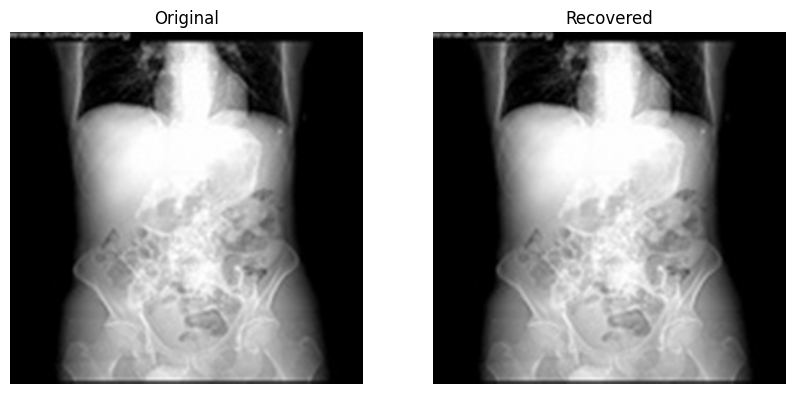

In [2]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def find_path(name, roots=['/kaggle/working', '/kaggle/input', '.']):
    for root in roots:
        for r, _, f in os.walk(root):
            if name in f: return os.path.join(r, name)
    return None

p1 = find_path("Abdominal.tiff")
p2 = find_path("Recovered.tiff", roots=['/kaggle/working'])

if p1 and p2:
    i1 = Image.open(p1).convert('L')
    i2 = Image.open(p2).convert('L')
    
    if i1.size != i2.size: i2 = i2.resize(i1.size)
    
    mse = np.mean((np.array(i1) - np.array(i2))**2)
    psnr = 20 * math.log10(255.0 / math.sqrt(mse)) if mse else float('inf')
    
    print(f"Src: {p1}")
    print(f"Rec: {p2}")
    print(f"PSNR: {psnr:.4f} dB")
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(i1, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
    ax[1].imshow(i2, cmap='gray'); ax[1].set_title(f"Recovered"); ax[1].axis('off')
    plt.show()
else:
    print("Files not found")

In [2]:
!rm /kaggle/working/!rm -rf /kaggle/working/*
